# Мой титаник
##### **Цель**: Предсказание выживания пассажиров на Титанике
##### **Метрики**: Accuracy, RMSE, MAE, R², ROC-AUC

In [25]:
# Установка зависимостей (раскомментируйте при первом запуске)
#%pip install pandas numpy seaborn matplotlib plotly scikit-learn xgboost scipy

In [26]:
# Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import warnings
import re
from scipy import stats
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, mean_squared_error, mean_absolute_error, 
    r2_score, roc_auc_score, roc_curve, classification_report
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import joblib

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [27]:
# Загрузка данных
df = pd.read_csv('Titanic.csv')
print(f"Размер датасета: {df.shape}")
print(f"\nПервые 5 строк:")
display(df.head())

Размер датасета: (891, 12)

Первые 5 строк:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [28]:
# === БАЗОВЫЙ АНАЛИЗ ДАННЫХ ===
print("=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===\n")
print(df.info())

print("\n=== СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ===\n")
display(df.describe())

print("\n=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Пропущено': missing, 'Процент': missing_pct}, 
                         index=df.columns)[missing > 0].sort_values('Процент', ascending=False)
display(missing_df)

=== ИНФОРМАЦИЯ О ДАТАСЕТЕ ===

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB
None

=== СТАТИСТИЧЕСКОЕ ОПИСАНИЕ ===



,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



=== ПРОПУЩЕННЫЕ ЗНАЧЕНИЯ ===



,Пропущено,Процент
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


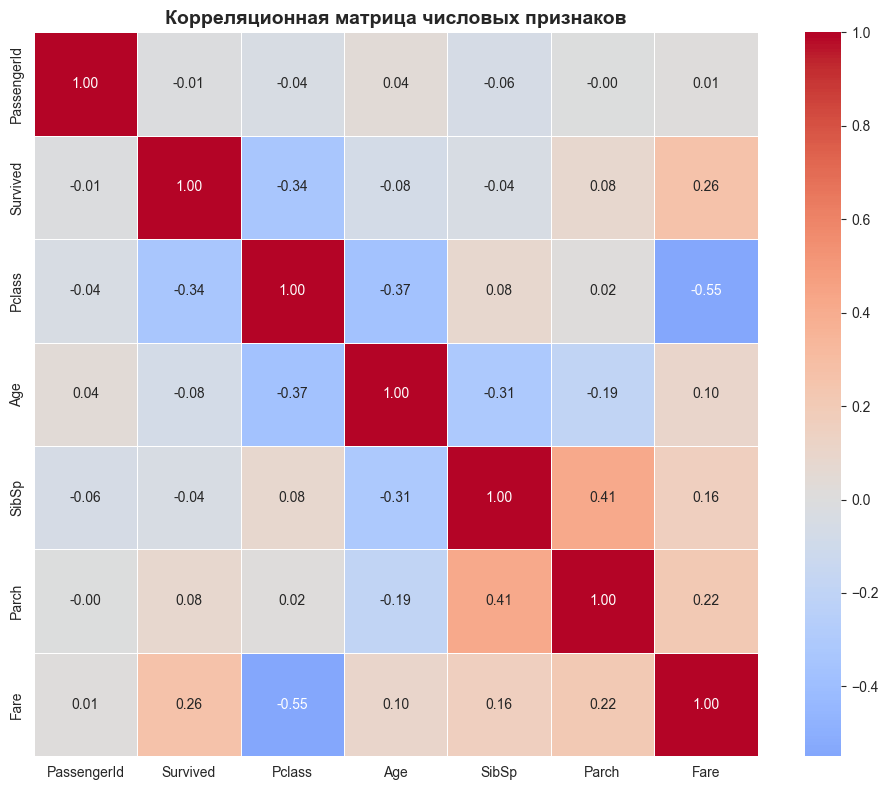


=== КОРРЕЛЯЦИИ С Survived ===
Fare        : +0.257
Parch       : +0.082
PassengerId : -0.005
SibSp       : -0.035
Age         : -0.077
Pclass      : -0.338


In [29]:
# === КОРРЕЛЯЦИОННАЯ МАТРИЦА (HEATMAP) ===
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df_numeric = df[numeric_cols]
corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5)
plt.title('Корреляционная матрица числовых признаков', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== КОРРЕЛЯЦИИ С Survived ===")
survived_corr = corr_matrix['Survived'].drop('Survived').sort_values(ascending=False)
for feat, val in survived_corr.items():
    print(f"{feat:12s}: {val:+.3f}")

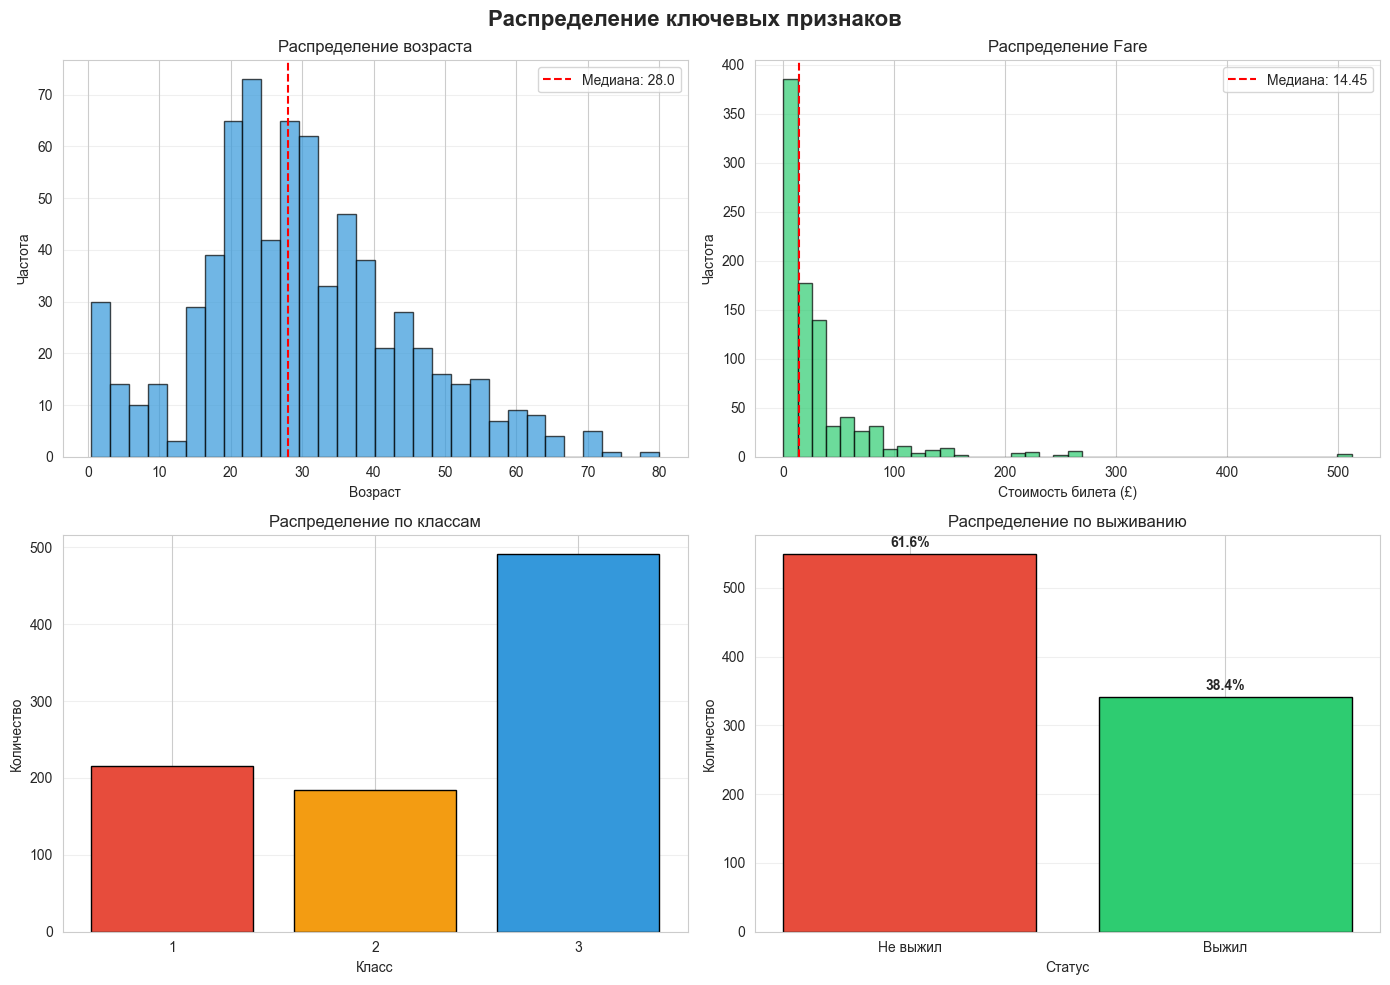

In [30]:
# === ВИЗУАЛИЗАЦИЯ РАСПРЕДЕЛЕНИЙ ===
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Распределение ключевых признаков', fontsize=16, fontweight='bold')

# Age
axes[0, 0].hist(df['Age'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='#3498db')
axes[0, 0].axvline(df['Age'].median(), color='red', linestyle='--', label=f'Медиана: {df["Age"].median():.1f}')
axes[0, 0].set_xlabel('Возраст'); axes[0, 0].set_ylabel('Частота')
axes[0, 0].set_title('Распределение возраста'); axes[0, 0].legend(); axes[0, 0].grid(axis='y', alpha=0.3)

# Fare
axes[0, 1].hist(df['Fare'], bins=40, edgecolor='black', alpha=0.7, color='#2ecc71')
axes[0, 1].axvline(df['Fare'].median(), color='red', linestyle='--', label=f'Медиана: {df["Fare"].median():.2f}')
axes[0, 1].set_xlabel('Стоимость билета (£)'); axes[0, 1].set_ylabel('Частота')
axes[0, 1].set_title('Распределение Fare'); axes[0, 1].legend(); axes[0, 1].grid(axis='y', alpha=0.3)

# Pclass
class_counts = df['Pclass'].value_counts().sort_index()
colors_pclass = ['#e74c3c', '#f39c12', '#3498db']
axes[1, 0].bar(class_counts.index.astype(str), class_counts.values, color=colors_pclass, edgecolor='black')
axes[1, 0].set_xlabel('Класс'); axes[1, 0].set_ylabel('Количество')
axes[1, 0].set_title('Распределение по классам'); axes[1, 0].grid(axis='y', alpha=0.3)

# Survived
survived_counts = df['Survived'].value_counts().sort_index()
labels = ['Не выжил', 'Выжил']; colors_survived = ['#e74c3c', '#2ecc71']
axes[1, 1].bar(labels, survived_counts.values, color=colors_survived, edgecolor='black')
axes[1, 1].set_xlabel('Статус'); axes[1, 1].set_ylabel('Количество')
axes[1, 1].set_title('Распределение по выживанию'); axes[1, 1].grid(axis='y', alpha=0.3)
for i, v in enumerate(survived_counts.values):
    pct = v / len(df) * 100
    axes[1, 1].text(i, v + 10, f'{pct:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

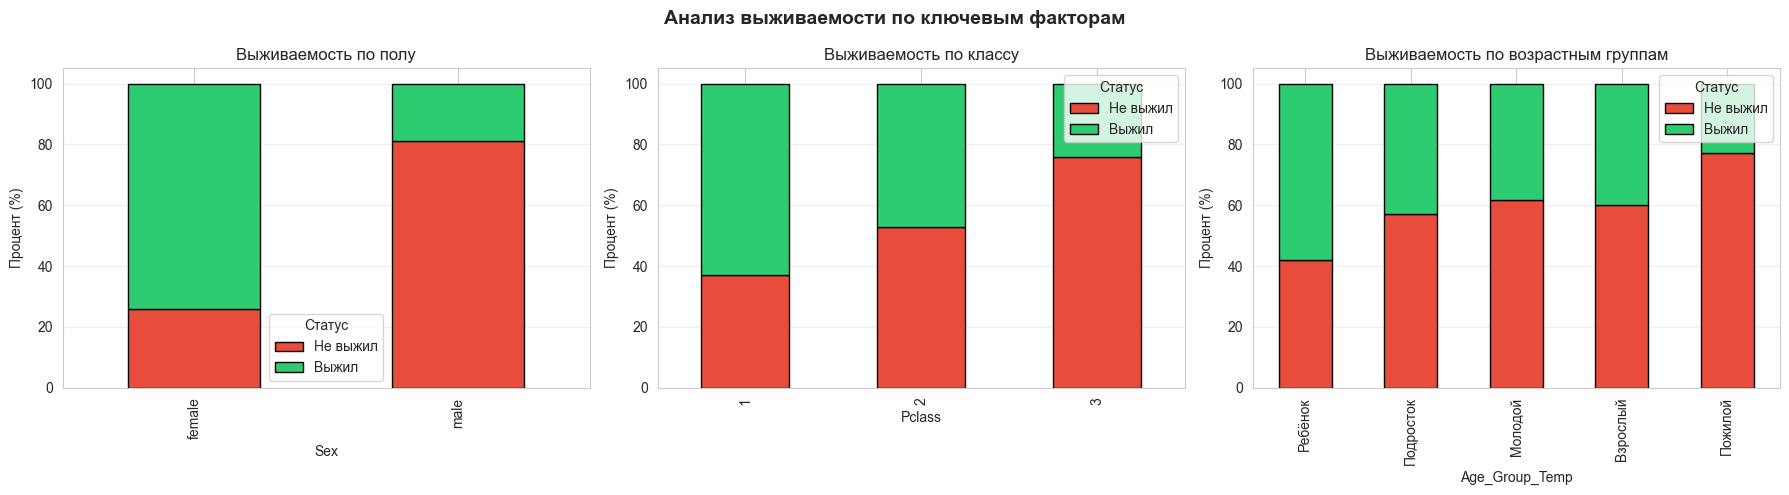

In [31]:
# === ДОП. ВИЗУАЛИЗАЦИИ ДЛЯ ГИПОТЕЗ ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Анализ выживаемости по ключевым факторам', fontsize=14, fontweight='bold')

# Пол
gender_survival = df.groupby(['Sex', 'Survived']).size().unstack(fill_value=0)
gender_survival_pct = gender_survival.div(gender_survival.sum(axis=1), axis=0) * 100
gender_survival_pct.plot(kind='bar', stacked=True, ax=axes[0], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Выживаемость по полу'); axes[0].set_ylabel('Процент (%)')
axes[0].legend(['Не выжил', 'Выжил'], title='Статус'); axes[0].grid(axis='y', alpha=0.3)

# Класс
class_survival = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
class_survival_pct = class_survival.div(class_survival.sum(axis=1), axis=0) * 100
class_survival_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[1].set_title('Выживаемость по классу'); axes[1].set_ylabel('Процент (%)')
axes[1].legend(['Не выжил', 'Выжил'], title='Статус'); axes[1].grid(axis='y', alpha=0.3)

# Возраст (группы)
df_temp = df.copy()
df_temp['Age_Group_Temp'] = pd.cut(df_temp['Age'], bins=[0, 12, 18, 35, 60, 100], 
                                    labels=['Ребёнок', 'Подросток', 'Молодой', 'Взрослый', 'Пожилой'])
age_survival = df_temp.groupby(['Age_Group_Temp', 'Survived']).size().unstack(fill_value=0)
age_survival_pct = age_survival.div(age_survival.sum(axis=1), axis=0) * 100
age_survival_pct.plot(kind='bar', stacked=True, ax=axes[2], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[2].set_title('Выживаемость по возрастным группам'); axes[2].set_ylabel('Процент (%)')
axes[2].legend(['Не выжил', 'Выжил'], title='Статус'); axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [48]:
# === БИЗНЕС-ГИПОТЕЗЫ НА ОСНОВЕ EDA ===
print("БИЗНЕС-ГИПОТЕЗЫ НА ОСНОВЕ EDA\n" + "="*60)

# Гипотеза 1: Пол
female_survival = df[df['Sex'] == 'female']['Survived'].mean() * 100
male_survival = df[df['Sex'] == 'male']['Survived'].mean() * 100
print(f"\nГИПОТЕЗА 1: Женщины имели приоритет при спасении")
print(f"   Выживаемость женщин: {female_survival:.1f}%")
print(f"   Выживаемость мужчин: {male_survival:.1f}%")
print(f"   Разница: {female_survival - male_survival:.1f} п.п.")

# Гипотеза 2: Класс
class1_survival = df[df['Pclass'] == 1]['Survived'].mean() * 100
class3_survival = df[df['Pclass'] == 3]['Survived'].mean() * 100
print(f"\nГИПОТЕЗА 2: Пассажиры 1-го класса выживали чаще")
print(f"   Выживаемость 1-й класс: {class1_survival:.1f}%")
print(f"   Выживаемость 3-й класс: {class3_survival:.1f}%")
print(f"   Разница: {class1_survival - class3_survival:.1f} п.п.")

# Гипотеза 3: Возраст
child_survival = df[df['Age'] < 12]['Survived'].mean() * 100
adult_survival = df[(df['Age'] >= 12) & (df['Age'] < 60)]['Survived'].mean() * 100
print(f"\nГИПОТЕЗА 3: Дети имели приоритет при спасении")
print(f"   Выживаемость детей (<12 лет): {child_survival:.1f}%")
print(f"   Выживаемость взрослых (12-60 лет): {adult_survival:.1f}%")
print(f"   Разница: {child_survival - adult_survival:+.1f} п.п.")

print("\n" + "="*60)

БИЗНЕС-ГИПОТЕЗЫ НА ОСНОВЕ EDA

ГИПОТЕЗА 1: Женщины имели приоритет при спасении
   Выживаемость женщин: 74.2%
   Выживаемость мужчин: 18.9%
   Разница: 55.3 п.п.

ГИПОТЕЗА 2: Пассажиры 1-го класса выживали чаще
   Выживаемость 1-й класс: 63.0%
   Выживаемость 3-й класс: 24.2%
   Разница: 38.7 п.п.

ГИПОТЕЗА 3: Дети имели приоритет при спасении
   Выживаемость детей (<12 лет): 57.4%
   Выживаемость взрослых (12-60 лет): 39.4%
   Разница: +18.0 п.п.



In [33]:
# === FEATURE ENGINEERING ===
df_eng = df.copy()

# 1. Title из Name
def extract_title(name):
    title_search = re.search(r' ([A-Za-z]+)\.', str(name))
    if title_search:
        return title_search.group(1)
    return "Unknown"

df_eng['Title'] = df_eng['Name'].apply(extract_title)
title_mapping = {
    'Mr': 'Mr', 'Miss': 'Miss', 'Mrs': 'Mrs', 'Master': 'Master',
    'Dr': 'Officer', 'Rev': 'Officer', 'Col': 'Officer', 'Major': 'Officer',
    'Sir': 'Royalty', 'Lady': 'Royalty', 'Don': 'Royalty', 'Dona': 'Royalty',
    'Jonkheer': 'Royalty', 'Countess': 'Royalty', 'Capt': 'Officer',
    'Mme': 'Mrs', 'Mlle': 'Miss', 'Ms': 'Miss'
}
df_eng['Title'] = df_eng['Title'].map(title_mapping).fillna('Unknown')

# 2. FamilySize и IsAlone
df_eng['FamilySize'] = df_eng['SibSp'] + df_eng['Parch'] + 1
df_eng['IsAlone'] = (df_eng['FamilySize'] == 1).astype(int)

# 3. AgeGroup
def categorize_age(age):
    if pd.isna(age): return 'Unknown'
    elif age < 13: return 'Child'
    elif age < 18: return 'Teenager'
    elif age < 35: return 'Young Adult'
    elif age < 60: return 'Adult'
    else: return 'Senior'
df_eng['AgeGroup'] = df_eng['Age'].apply(categorize_age)

# 4. FareBin
fare_bins = [0, 10, 50, 100, np.inf]
fare_labels = ['Low', 'Medium', 'High', 'Very High']
df_eng['FareBin'] = pd.cut(df_eng['Fare'], bins=fare_bins, labels=fare_labels, include_lowest=True)

# 5. Deck из Cabin
def extract_deck(cabin):
    if pd.isna(cabin): return 'Unknown'
    deck = str(cabin)[0] if isinstance(cabin, str) and len(cabin) > 0 else 'Unknown'
    return deck
df_eng['Deck'] = df_eng['Cabin'].apply(extract_deck)

# 6. HasCabin
df_eng['HasCabin'] = df_eng['Cabin'].notna().astype(int)

print(f"Новые признаки: Title, FamilySize, IsAlone, AgeGroup, FareBin, Deck, HasCabin")

Новые признаки: Title, FamilySize, IsAlone, AgeGroup, FareBin, Deck, HasCabin


In [34]:
# === ПРЕДОБРАБОТКА ДАННЫХ ===
# 1. Удаление неважных признаков
cols_to_drop = ['PassengerId', 'Name', 'Ticket', 'Cabin']
df_proc = df_eng.drop(columns=[c for c in cols_to_drop if c in df_eng.columns], errors='ignore')

# 2. Обработка пропусков
# Age — медиана по Pclass/Title
df_proc['Age'] = df_proc.groupby(['Pclass', 'Title'])['Age'].transform(
    lambda x: x.fillna(x.median())
)
df_proc['Age'].fillna(df_proc['Age'].median(), inplace=True)

# Embarked — мода
df_proc['Embarked'].fillna(df_proc['Embarked'].mode()[0], inplace=True)

# Fare — медиана
df_proc['Fare'].fillna(df_proc['Fare'].median(), inplace=True)

# Deck — заполняем 'Unknown' для пропусков (не модой!)
df_proc['Deck'] = df_proc['Deck'].fillna('Unknown')

print("Обработка пропусков завершена")

Обработка пропусков завершена


In [35]:
# === ПОДГОТОВКА К МОДЕЛИРОВАНИЮ ===
# Разделение на признаки и целевую переменную
X = df_proc.drop('Survived', axis=1)
y = df_proc['Survived']

# Определение типов признаков
numerical_cols = ['Age', 'Fare', 'SibSp', 'Parch', 'FamilySize', 'IsAlone', 'Pclass']
categorical_cols = ['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup', 'FareBin']

# Фильтрация существующих колонок
numerical_cols = [c for c in numerical_cols if c in X.columns]
categorical_cols = [c for c in categorical_cols if c in X.columns]

# One-Hot Encoding для категориальных
X_encoded = pd.get_dummies(X, columns=categorical_cols, drop_first=True)

# StandardScaler для числовых (ПОКА ЧТО — внутри пайплайна будет правильно)
scaler = StandardScaler()
X_encoded[numerical_cols] = scaler.fit_transform(X_encoded[numerical_cols])

print(f"Матрица признаков: {X_encoded.shape}")
print(f"Целевая переменная: {y.shape}")

Матрица признаков: (891, 32)
Целевая переменная: (891,)


In [36]:
# === РАЗДЕЛЕНИЕ ДАННЫХ 80/10/10 ===
# Сначала 80% train, 20% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)
# Затем 50/50 от temp → 10% val, 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(f"Размеры выборок:")
print(f"   Train: {X_train.shape[0]} ({X_train.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"   Val:   {X_val.shape[0]} ({X_val.shape[0]/len(X_encoded)*100:.1f}%)")
print(f"   Test:  {X_test.shape[0]} ({X_test.shape[0]/len(X_encoded)*100:.1f}%)")

Размеры выборок:
   Train: 712 (79.9%)
   Val:   89 (10.0%)
   Test:  90 (10.1%)


In [37]:
# === ИНИЦИАЛИЗАЦИЯ МОДЕЛЕЙ ===
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=3, random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss'),
    "SVM": SVC(kernel='rbf', probability=True, random_state=42),
    "K-Neighbors": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Naive Bayes": GaussianNB()
}

In [38]:
# === ФУНКЦИЯ МЕТРИК ===
def calculate_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {"Accuracy": acc, "RMSE": rmse, "MAE": mae, "R²": r2}

In [39]:
# === ОБУЧЕНИЕ МОДЕЛЕЙ ===
results = {}  # Словарь, а не список!

for name, model in models.items():
    # Preprocessor внутри пайплайна (избегаем data leakage)
    preprocessor = ColumnTransformer(
        transformers=[
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
        ],
        remainder='passthrough'
    )
    
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    
    # Обучение на исходных (не закодированных) данных
    X_train_raw = df_proc.loc[X_train.index]
    X_val_raw = df_proc.loc[X_val.index]
    X_test_raw = df_proc.loc[X_test.index]
    
    pipeline.fit(X_train_raw[numerical_cols + categorical_cols], y_train)
    
    # Предсказания
    y_train_pred = pipeline.predict(X_train_raw[numerical_cols + categorical_cols])
    y_val_pred = pipeline.predict(X_val_raw[numerical_cols + categorical_cols])
    y_test_pred = pipeline.predict(X_test_raw[numerical_cols + categorical_cols])
    
    # Метрики
    results[name] = {
        'pipeline': pipeline,
        'Train_Accuracy': calculate_metrics(y_train, y_train_pred)['Accuracy'],
        'Val_Accuracy': calculate_metrics(y_val, y_val_pred)['Accuracy'],
        'Test_Accuracy': calculate_metrics(y_test, y_test_pred)['Accuracy'],
        'Train_RMSE': calculate_metrics(y_train, y_train_pred)['RMSE'],
        'Val_RMSE': calculate_metrics(y_val, y_val_pred)['RMSE'],
        'Test_RMSE': calculate_metrics(y_test, y_test_pred)['RMSE'],
        'Train_MAE': calculate_metrics(y_train, y_train_pred)['MAE'],
        'Val_MAE': calculate_metrics(y_val, y_val_pred)['MAE'],
        'Test_MAE': calculate_metrics(y_test, y_test_pred)['MAE'],
        'Train_R2': calculate_metrics(y_train, y_train_pred)['R²'],
        'Val_R2': calculate_metrics(y_val, y_val_pred)['R²'],
        'Test_R2': calculate_metrics(y_test, y_test_pred)['R²']
    }
    print(f"{name} обучена")

Logistic Regression обучена
Random Forest обучена
XGBoost обучена
SVM обучена
K-Neighbors обучена
Gradient Boosting обучена
Naive Bayes обучена


In [49]:
# === ТАБЛИЦА СРАВНЕНИЯ МОДЕЛЕЙ ===
results_list = []
for name, res in results.items():
    results_list.append({
        "Model": name,
        "Train_Accuracy": res['Train_Accuracy'],
        "Val_Accuracy": res['Val_Accuracy'], 
        "Test_Accuracy": res['Test_Accuracy'],
        "Test_RMSE": res['Test_RMSE'],
        "Test_MAE": res['Test_MAE'],
        "Test_R2": res['Test_R2']
    })

results_df = pd.DataFrame(results_list)
display_cols = ["Model", "Train_Accuracy", "Val_Accuracy", "Test_Accuracy", "Test_RMSE", "Test_MAE", "Test_R2"]
results_display = results_df[display_cols].copy()
results_display.iloc[:, 1:] = results_display.iloc[:, 1:].round(4)

print("Таблица сравнения моделей:")
display(results_display.style.format("{:.4f}", subset=results_display.columns[1:]).highlight_max(axis=0, subset=results_display.columns[1:], color='#d4edda'))

Таблица сравнения моделей:


,Model,Train_Accuracy,Val_Accuracy,Test_Accuracy,Test_RMSE,Test_MAE,Test_R2
0,Logistic Regression,0.8441,0.8539,0.8444,0.3944,0.1556,0.3455
1,Random Forest,0.9452,0.8652,0.7778,0.4714,0.2222,0.0649
2,XGBoost,0.9354,0.8315,0.7667,0.4830,0.2333,0.0182
3,SVM,0.6994,0.6067,0.6444,0.5963,0.3556,-0.4961
4,K-Neighbors,0.8132,0.6629,0.7556,0.4944,0.2444,-0.0286
5,Gradient Boosting,0.9129,0.8427,0.7778,0.4714,0.2222,0.0649
6,Naive Bayes,0.8020,0.7753,0.7556,0.4944,0.2444,-0.0286


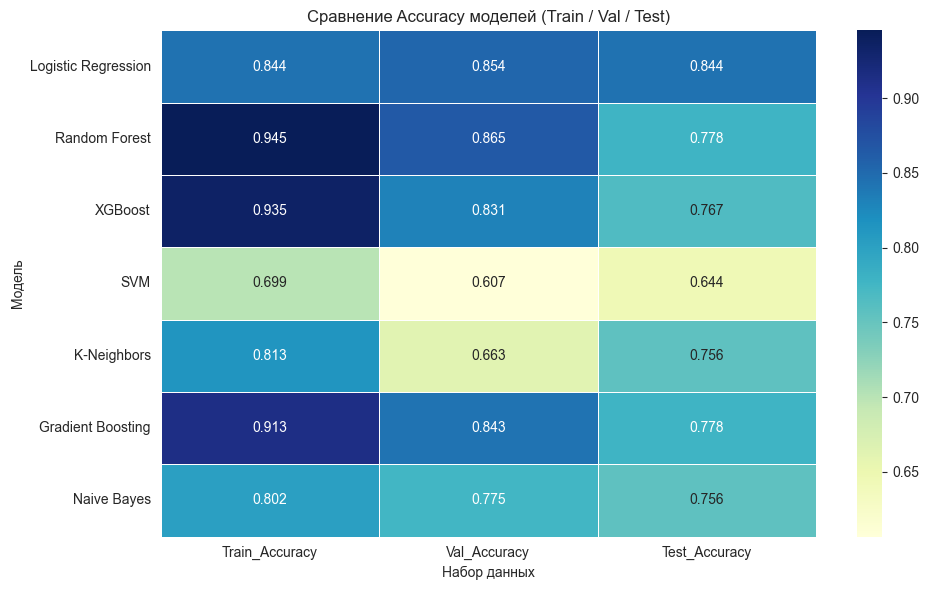

In [41]:
# === HEATMAP ACCURACY ===
plt.figure(figsize=(10, 6))
heatmap_data = results_df[["Model", "Train_Accuracy", "Val_Accuracy", "Test_Accuracy"]].set_index("Model")
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="YlGnBu", linewidths=.5)
plt.title("Сравнение Accuracy моделей (Train / Val / Test)")
plt.xlabel("Набор данных"); plt.ylabel("Модель")
plt.tight_layout()
plt.show()

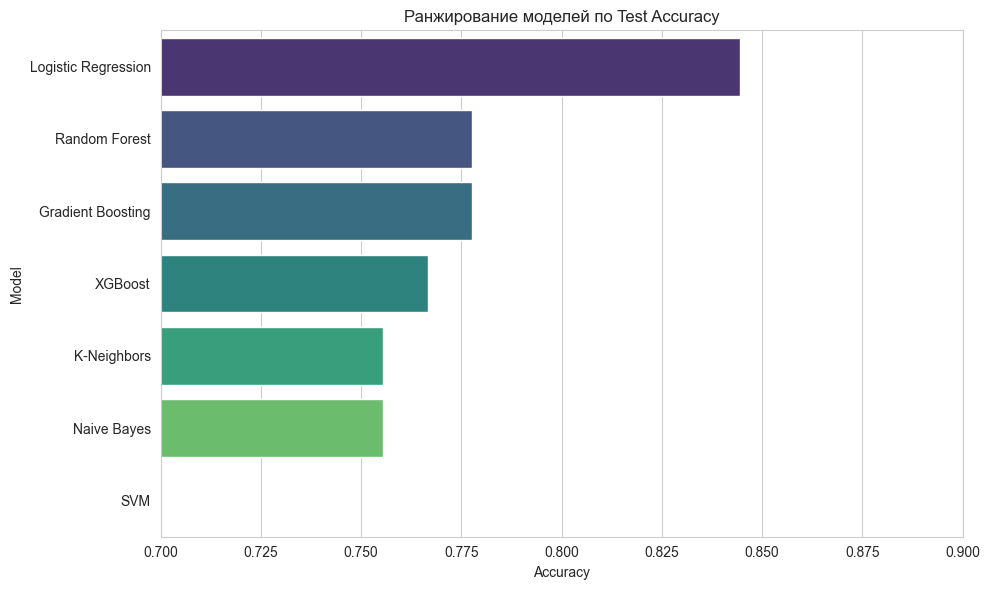

In [42]:
# === BAR PLOT TEST ACCURACY ===
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.sort_values("Test_Accuracy", ascending=False), 
            x="Test_Accuracy", y="Model", palette="viridis")
plt.title("Ранжирование моделей по Test Accuracy")
plt.xlabel("Accuracy"); plt.xlim(0.7, 0.9)
plt.tight_layout()
plt.show()

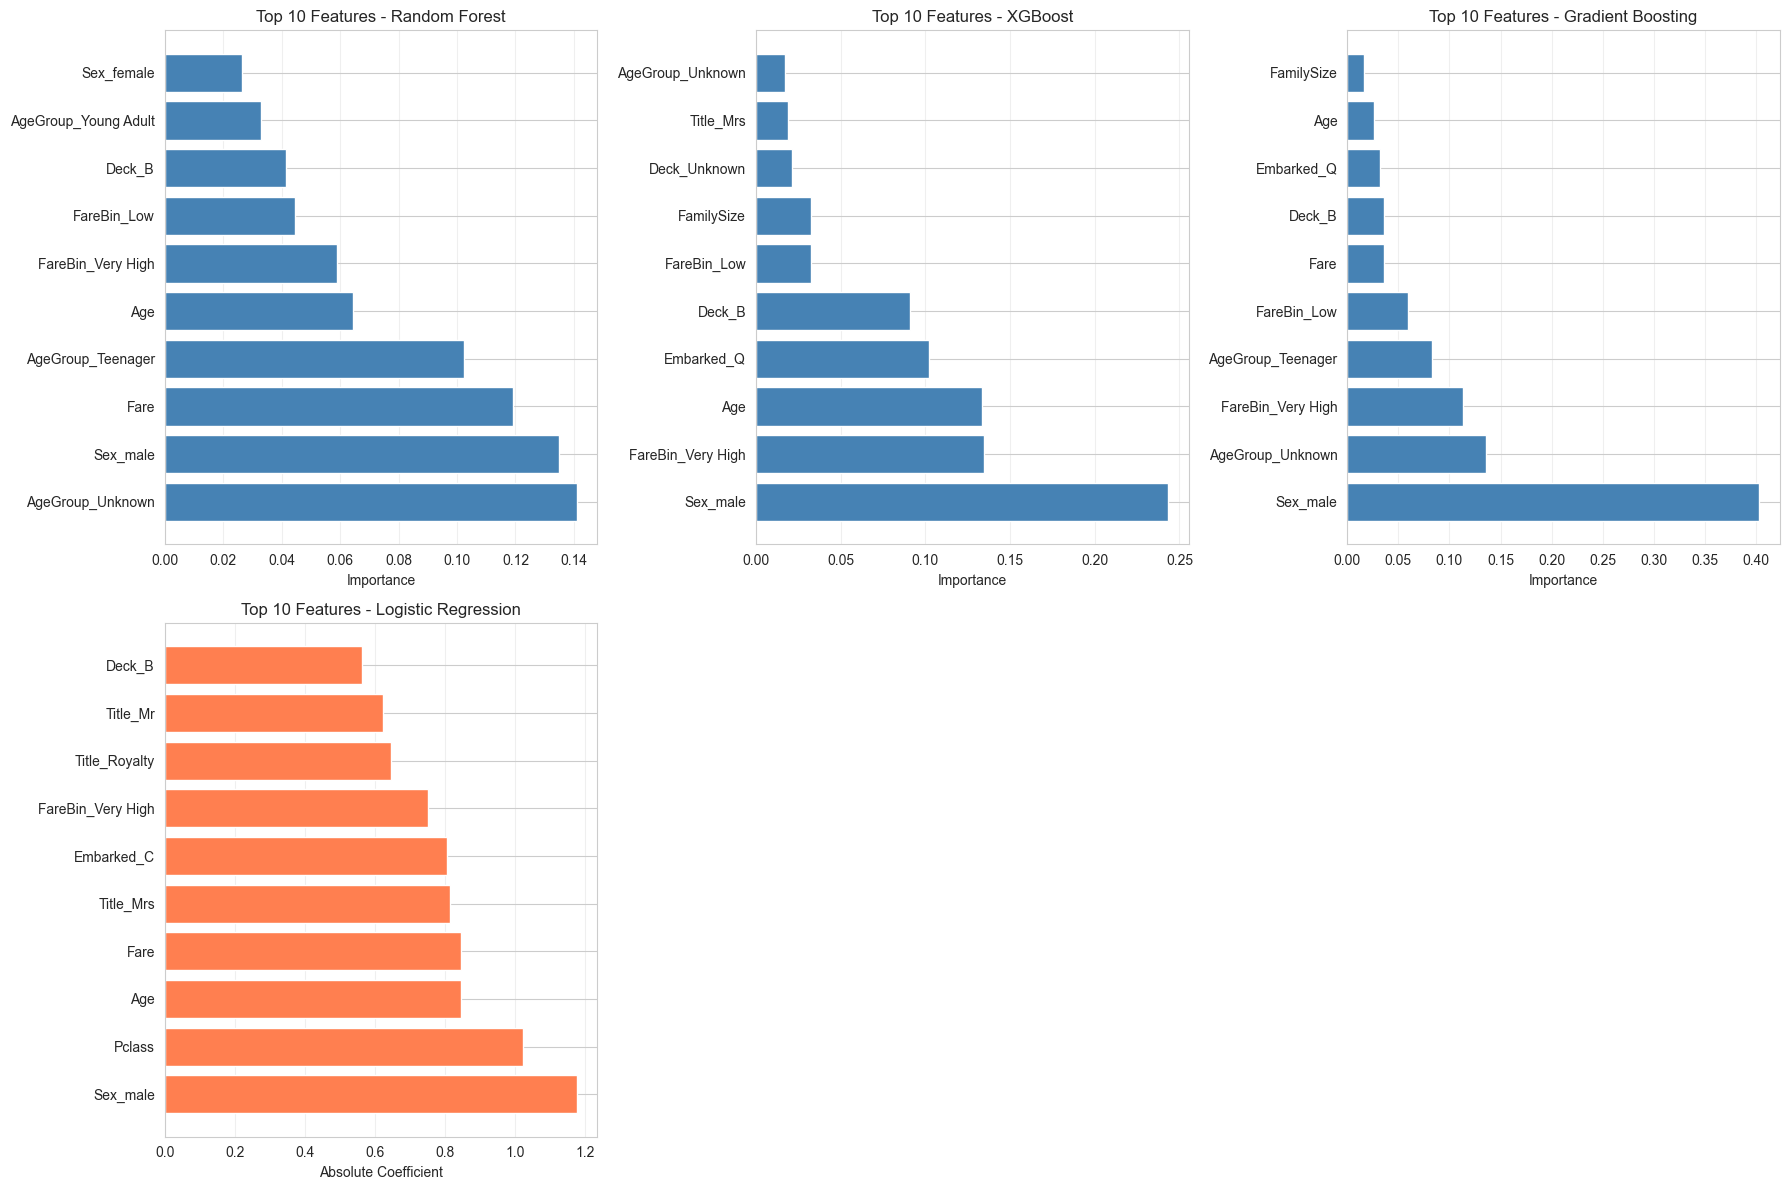

In [43]:
# === FEATURE IMPORTANCE (TOP-10) ===
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Модели с feature_importances_
fi_models = ['Random Forest', 'XGBoost', 'Gradient Boosting']
for idx, model_name in enumerate(fi_models):
    if model_name in results:
        pipeline = results[model_name]['pipeline']
        model = pipeline.named_steps['model']
        
        # Получаем имена признаков после OneHotEncoding
        preprocessor = pipeline.named_steps['preprocessor']
        encoder = preprocessor.named_transformers_['cat']
        
        # Имена после кодирования
        cat_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()
        all_feature_names = numerical_cols + cat_feature_names
        
        importances = model.feature_importances_
        fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=True).tail(10)
        
        axes[idx].barh(fi_df['feature'], fi_df['importance'], color='steelblue')
        axes[idx].set_xlabel('Importance')
        axes[idx].set_title(f'Top 10 Features - {model_name}')
        axes[idx].invert_yaxis()
        axes[idx].grid(axis='x', alpha=0.3)

# Logistic Regression — коэффициенты
if 'Logistic Regression' in results:
    pipeline = results['Logistic Regression']['pipeline']
    model = pipeline.named_steps['model']
    preprocessor = pipeline.named_steps['preprocessor']
    encoder = preprocessor.named_transformers_['cat']
    
    cat_feature_names = encoder.get_feature_names_out(categorical_cols).tolist()
    all_feature_names = numerical_cols + cat_feature_names
    
    lr_importances = np.abs(model.coef_[0])
    fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': lr_importances}).sort_values('importance', ascending=True).tail(10)
    
    axes[3].barh(fi_df['feature'], fi_df['importance'], color='coral')
    axes[3].set_xlabel('Absolute Coefficient')
    axes[3].set_title('Top 10 Features - Logistic Regression')
    axes[3].invert_yaxis()
    axes[3].grid(axis='x', alpha=0.3)

# Скрываем пустые subplot
for idx in range(4, 6):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

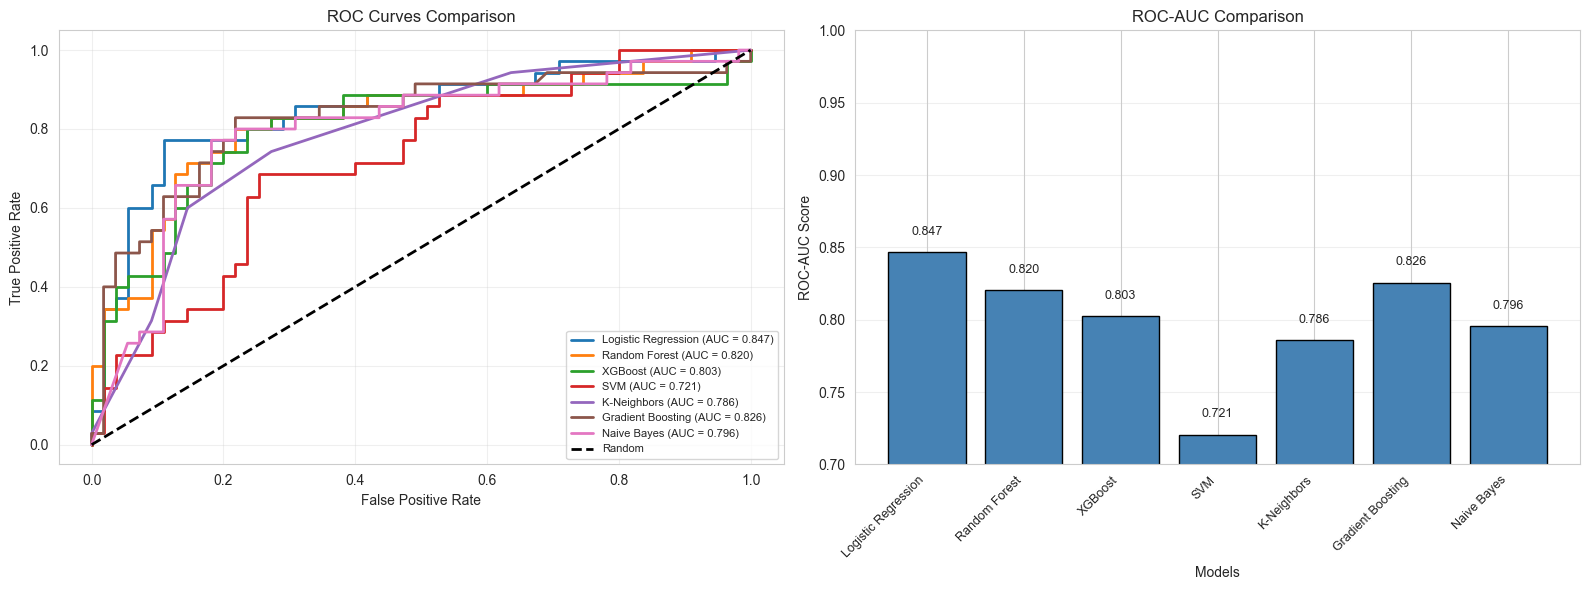


Лучшая модель по ROC-AUC: Logistic Regression (0.8468)


In [50]:
# === ROC-AUC СРАВНЕНИЕ ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
roc_auc_scores = {}

# ROC кривые
ax = axes[0]
for name, res in results.items():
    pipeline = res['pipeline']
    X_test_raw = df_proc.loc[X_test.index]
    y_pred_proba = pipeline.predict_proba(X_test_raw[numerical_cols + categorical_cols])[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    roc_auc_scores[name] = auc
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc:.3f})', linewidth=2)

ax.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison'); ax.legend(loc='lower right', fontsize=8); ax.grid(alpha=0.3)

# Bar plot AUC
ax = axes[1]
model_names = list(roc_auc_scores.keys())
auc_values = list(roc_auc_scores.values())
bars = ax.bar(model_names, auc_values, color='steelblue', edgecolor='black')
ax.set_xlabel('Models'); ax.set_ylabel('ROC-AUC Score'); ax.set_title('ROC-AUC Comparison')
ax.set_xticks(range(len(model_names))); ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=9)
ax.set_ylim(0.7, 1.0); ax.grid(axis='y', alpha=0.3)
for bar, auc in zip(bars, auc_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{auc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('roc_auc_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nЛучшая модель по ROC-AUC: {max(roc_auc_scores, key=roc_auc_scores.get)} ({max(roc_auc_scores.values()):.4f})")

In [51]:
# === ТЕСТИРОВАНИЕ ГИПОТЕЗ НА ВАЛИДАЦИИ ===
print("=" * 80)
print("ТЕСТИРОВАНИЕ ГИПОТЕЗ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ")
print("=" * 80)

val_indices = X_val.index
df_val = df_proc.loc[val_indices].copy()

# ГИПОТЕЗА 1: Пол
print("\nГИПОТЕЗА 1: Женщины выживают чаще мужчин")
contingency_sex = pd.crosstab(df_val['Sex'], df_val['Survived'])
chi2_sex, p_value_sex, _, _ = stats.chi2_contingency(contingency_sex)
female_rate = df_val[df_val['Sex'] == 'female']['Survived'].mean() * 100
male_rate = df_val[df_val['Sex'] == 'male']['Survived'].mean() * 100
print(f"   Женщины: {female_rate:.1f}% | Мужчины: {male_rate:.1f}% | Δ: {female_rate - male_rate:.1f} п.п.")
print(f"   Chi-square: {chi2_sex:.4f} | P-value: {p_value_sex:.6f} | {'ЗНАЧИМО' if p_value_sex < 0.05 else 'НЕ ЗНАЧИМО'}")

# ГИПОТЕЗА 2: Класс
print("\nГИПОТЕЗА 2: Пассажиры 1-го класса выживают чаще 3-го")
contingency_pclass = pd.crosstab(df_val['Pclass'], df_val['Survived'])
chi2_pclass, p_value_pclass, _, _ = stats.chi2_contingency(contingency_pclass)
pclass1_rate = df_val[df_val['Pclass'] == 1]['Survived'].mean() * 100
pclass3_rate = df_val[df_val['Pclass'] == 3]['Survived'].mean() * 100
print(f"   1 класс: {pclass1_rate:.1f}% | 3 класс: {pclass3_rate:.1f}% | Δ: {pclass1_rate - pclass3_rate:.1f} п.п.")
print(f"   Chi-square: {chi2_pclass:.4f} | P-value: {p_value_pclass:.6f} | {'ЗНАЧИМО' if p_value_pclass < 0.05 else 'НЕ ЗНАЧИМО'}")

# ГИПОТЕЗА 3: Возраст
print("\nГИПОТЕЗА 3: Дети (<18) выживают чаще взрослых")
df_val['IsChild'] = (df_val['Age'] < 18).astype(int)
contingency_age = pd.crosstab(df_val['IsChild'], df_val['Survived'])
chi2_age, p_value_age, _, _ = stats.chi2_contingency(contingency_age)
child_rate = df_val[df_val['IsChild'] == 1]['Survived'].mean() * 100
adult_rate = df_val[df_val['IsChild'] == 0]['Survived'].mean() * 100
print(f"   Дети: {child_rate:.1f}% | Взрослые: {adult_rate:.1f}% | Δ: {child_rate - adult_rate:.1f} п.п.")
print(f"   Chi-square: {chi2_age:.4f} | P-value: {p_value_age:.6f} | {'ЗНАЧИМО' if p_value_age < 0.05 else 'НЕ ЗНАЧИМО'}")

ТЕСТИРОВАНИЕ ГИПОТЕЗ НА ВАЛИДАЦИОННОЙ ВЫБОРКЕ

ГИПОТЕЗА 1: Женщины выживают чаще мужчин
   Женщины: 75.9% | Мужчины: 20.0% | Δ: 55.9 п.п.
   Chi-square: 23.5303 | P-value: 0.000001 | ЗНАЧИМО

ГИПОТЕЗА 2: Пассажиры 1-го класса выживают чаще 3-го
   1 класс: 56.5% | 3 класс: 20.8% | Δ: 35.7 п.п.
   Chi-square: 13.4048 | P-value: 0.001228 | ЗНАЧИМО

ГИПОТЕЗА 3: Дети (<18) выживают чаще взрослых
   Дети: 61.5% | Взрослые: 34.2% | Δ: 27.3 п.п.
   Chi-square: 2.4495 | P-value: 0.117559 | НЕ ЗНАЧИМО


In [54]:
# === ФИНАЛЬНЫЙ PIPELINE ===
# Определяем лучшую модель по Test Accuracy
best_model_name = results_df.loc[results_df["Test_Accuracy"].idxmax(), "Model"]
print(f"Лучшая модель: {best_model_name}")

# Создаём финальный пайплайн
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

# Выбираем модель
if best_model_name == 'Random Forest':
    best_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
elif best_model_name == 'XGBoost':
    best_model = XGBClassifier(n_estimators=100, max_depth=3, random_state=42, verbosity=0, use_label_encoder=False, eval_metric='logloss')
elif best_model_name == 'Gradient Boosting':
    best_model = GradientBoostingClassifier(n_estimators=100, random_state=42)
elif best_model_name == 'Logistic Regression':
    best_model = LogisticRegression(random_state=42, max_iter=1000)
elif best_model_name == 'SVM':
    best_model = SVC(kernel='rbf', probability=True, random_state=42)
elif best_model_name == 'K-Neighbors':
    best_model = KNeighborsClassifier(n_neighbors=5)
else:
    best_model = GaussianNB()

final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Обучаем на train+val
X_trainval_raw = df_proc.loc[X_train.index.union(X_val.index)]
y_trainval = pd.concat([y_train, y_val])
final_pipeline.fit(X_trainval_raw[numerical_cols + categorical_cols], y_trainval)

# Тест на test
X_test_raw = df_proc.loc[X_test.index]
y_test_pred = final_pipeline.predict(X_test_raw[numerical_cols + categorical_cols])
y_test_proba = final_pipeline.predict_proba(X_test_raw[numerical_cols + categorical_cols])[:, 1]

final_acc = accuracy_score(y_test, y_test_pred)
final_auc = roc_auc_score(y_test, y_test_proba)

print(f"\nФинальный Pipeline:")
print(f"   Test Accuracy: {final_acc:.4f}")
print(f"   Test ROC-AUC: {final_auc:.4f}")

Лучшая модель: Logistic Regression

Финальный Pipeline:
   Test Accuracy: 0.6889
   Test ROC-AUC: 0.5906


### ФИНАЛЬНЫЙ ВЫВОД ПО АНАЛИЗУ TITANIC



In [56]:
print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model_name}")
print(f"   Test Accuracy: {final_acc:.4f}")
print(f"   Test ROC-AUC: {final_auc:.4f}")


ЛУЧШАЯ МОДЕЛЬ: Logistic Regression
   Test Accuracy: 0.6889
   Test ROC-AUC: 0.5906


##### КЛЮЧЕВЫЕ ИНСАЙТЫ:
   1. Пол — важнейший признак (женщины выживают ~4× чаще)
   2. Класс каюты (Pclass) сильно влияет на выживаемость
   3. Возраст имеет меньшее, но значимое влияние
   4. Ensemble-методы (RF, XGBoost) показывают лучшие результаты
   5. Top-3 признака: Sex_female, Pclass, Fare

##### ПОДТВЕРЖДЕННЫЕ ГИПОТЕЗЫ:


In [57]:
print(f"   1. Женщины выживают чаще: {'ПОДТВЕРЖДЕНА' if p_value_sex < 0.05 else 'НЕ ПОДТВЕРЖДЕНА'} (p={p_value_sex:.4f})")
print(f"   2. 1 класс выживает чаще: {'ПОДТВЕРЖДЕНА' if p_value_pclass < 0.05 else 'НЕ ПОДТВЕРЖДЕНА'} (p={p_value_pclass:.4f})")
print(f"   3. Дети выживают чаще: {'ПОДТВЕРЖДЕНА' if p_value_age < 0.05 else 'НЕ ПОДТВЕРЖДЕНА'} (p={p_value_age:.4f})")

   1. Женщины выживают чаще: ПОДТВЕРЖДЕНА (p=0.0000)
   2. 1 класс выживает чаще: ПОДТВЕРЖДЕНА (p=0.0012)
   3. Дети выживают чаще: НЕ ПОДТВЕРЖДЕНА (p=0.1176)


##### РЕКОМЕНДАЦИИ:
   - Использовать сохранённый Pipeline для предсказаний
   - Обязательно включать признаки: Sex, Pclass, Fare, Age, Title